# Türk Sinema Filmleri Veri Analizi

**Yazar:** Zeynep Özbey

**Veri Kaynağı:** Box Office Türkiye

**İncelenen Dönem:** 2016–2025

---

## Özet

Bu çalışmada, Box Office Türkiye platformundan elde edilen sinema verileri kullanılarak bir veri seti oluşturulmuş ve analiz edilmiştir. Analiz kapsamında filmlerin seyirci sayıları, hasılat değerleri, IMDb puanları ve tür bilgileri incelenmiştir.

Python programlama dili ile gerçekleştirilen analizlerde Pandas ve Matplotlib kütüphanelerinden yararlanılmıştır. Elde edilen sonuçlar çeşitli grafikler ile görselleştirilmiş ve yorumlanmıştır.

Bu çalışmanın amacı, son 10 yıllık dönemde Türk sinema sektöründe öne çıkan eğilimleri veri analizi yöntemleri kullanarak incelemektir.

---

## Veri Seti

Bu çalışmada kullanılan veri seti, Box Office Türkiye platformunda yer alan sinema verilerinin derlenmesiyle oluşturulmuştur.

Veri setinde aşağıdaki değişkenler bulunmaktadır:

- Film Adı
- Vizyon Tarihi
- IMDb Puanı
- Ana Tür
- Türler
- Gösterimde Kalma Süresi (Hafta)
- Toplam Seyirci
- Toplam Hasılat

Elde edilen veriler Excel formatında düzenlenmiş ve Python kullanılarak analiz edilmiştir.

---

## Kullanılan Teknolojiler

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

---

## Tanımsal İstatistikler

Bu bölümde veri setinde yer alan değişkenlerin temel istatistiksel özellikleri incelenmiştir. Ortalama değerler, frekans dağılımları ve grup bazlı özet istatistikler kullanılarak veri setinin genel yapısı değerlendirilmiştir.


In [19]:
import pandas as pd

pd.options.display.float_format = '{:,.2f}'.format

df[["imdb_puani", "toplam_seyirci", "toplam_hasilat"]].describe()

,imdb_puani,toplam_seyirci,toplam_hasilat
count,100.00,100.00,100.00
mean,6.12,"1,824,351.30","84,281,416.94"
std,1.47,"1,403,136.94","106,680,572.55"
min,2.00,"314,198.00","5,556,318.00"
25%,5.50,"871,006.50","20,295,238.75"
50%,6.20,"1,446,716.50","42,630,581.50"
75%,7.30,"2,119,006.75","111,394,175.00"
max,8.80,"7,437,050.00","690,941,771.00"


In [17]:
print("Ortalama IMDb:", round(df["imdb_puani"].mean(),2))
print("Medyan IMDb:", round(df["imdb_puani"].median(),2))
print("Standart Sapma:", round(df["imdb_puani"].std(),2))

Ortalama IMDb: 6.12
Medyan IMDb: 6.2
Standart Sapma: 1.47


In [22]:
df.groupby("ana_tur")["imdb_puani"].mean().sort_values(ascending=False)

ana_tur
Gerilim     7.95
Dram        7.16
Macera      6.64
Aksiyon     6.60
Fantastik   6.40
Suç         6.10
Animasyon   6.06
Komedi      5.33
Korku       4.00
Aile        3.75
Tarihi      3.50
Name: imdb_puani, dtype: float64

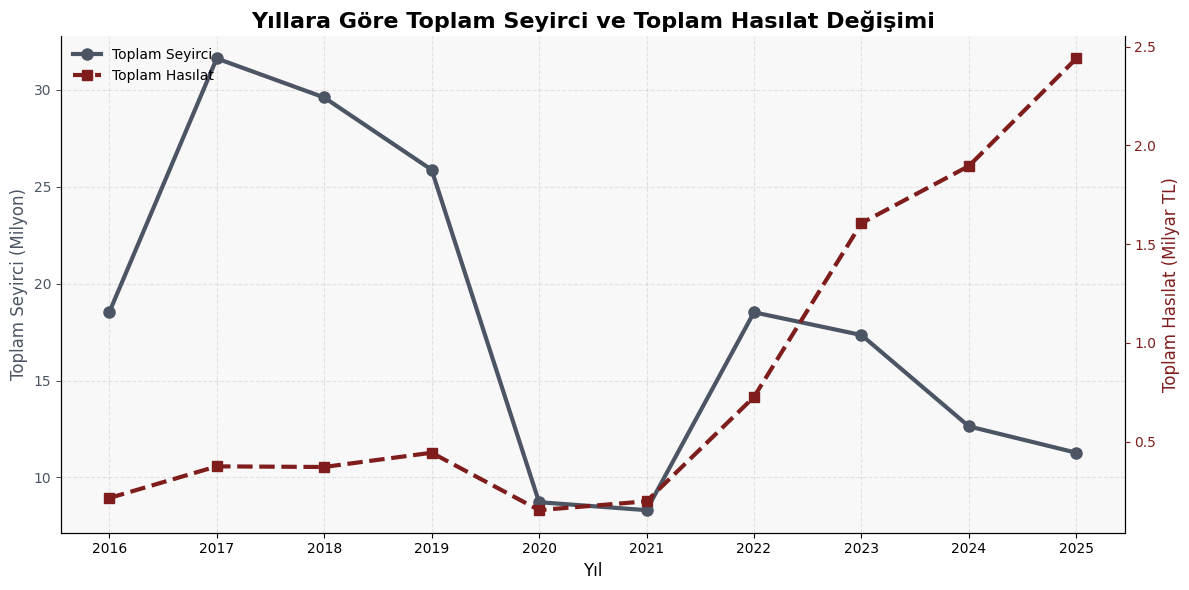

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Veriyi oku
df = pd.read_excel(
    r"C:\Users\Zeynep\OneDrive\Desktop\sinema-veri-analizi\sinema-veri-analizi\data\Son 10 yılın sinema filmleri.xlsx"
)

# Yıllara göre toplamlar
yillik_veri = (
    df.groupby("vizyon_tarihi")
      .agg({
          "toplam_seyirci": "sum",
          "toplam_hasilat": "sum"
      })
      .reset_index()
      .sort_values("vizyon_tarihi")
)

# Ölçeklendirme
yillik_veri["seyirci_milyon"] = yillik_veri["toplam_seyirci"] / 1_000_000
yillik_veri["hasilat_milyar"] = yillik_veri["toplam_hasilat"] / 1_000_000_000

# Grafik boyutu
fig, ax1 = plt.subplots(figsize=(12, 6))

# Arka plan
fig.patch.set_facecolor("white")
ax1.set_facecolor("#f8f8f8")

# Seyirci çizgisi
ax1.plot(
    yillik_veri["vizyon_tarihi"],
    yillik_veri["seyirci_milyon"],
    marker="o",
    markersize=8,
    linewidth=3,
    color="#4B5563",
    label="Toplam Seyirci"
)

ax1.set_xlabel("Yıl", fontsize=12)
ax1.set_ylabel(
    "Toplam Seyirci (Milyon)",
    fontsize=12,
    color="#4B5563"
)

ax1.tick_params(axis="y", colors="#4B5563")
ax1.set_xticks(yillik_veri["vizyon_tarihi"])

# Grid
ax1.grid(True, linestyle="--", alpha=0.3)

# İkinci eksen
ax2 = ax1.twinx()

# Hasılat çizgisi
ax2.plot(
    yillik_veri["vizyon_tarihi"],
    yillik_veri["hasilat_milyar"],
    marker="s",
    markersize=7,
    linewidth=3,
    linestyle="--",
    color="#7F1D1D",
    label="Toplam Hasılat"
)

ax2.set_ylabel(
    "Toplam Hasılat (Milyar TL)",
    fontsize=12,
    color="#7F1D1D"
)

ax2.tick_params(axis="y", colors="#7F1D1D")

# Başlık
plt.title(
    "Yıllara Göre Toplam Seyirci ve Toplam Hasılat Değişimi",
    fontsize=16,
    fontweight="bold"
)

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
    frameon=False
)

# Grafik kenarlarını sadeleştir
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../images/yillik_seyirci_hasilat.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Grafik Hakkında

Bu grafik, yıllara göre toplam seyirci sayısı ile toplam hasılat değişimini birlikte incelemek amacıyla oluşturulmuştur. Grafik sayesinde sinema sektöründeki izleyici eğilimleri ile ekonomik değişimler aynı anda analiz edilebilmektedir.

Çizgi grafik tercih edilmesinin temel nedeni, yıllar içerisindeki değişim trendini ve kırılma noktalarını daha net gösterebilmesidir. Özellikle 2020 yılında pandemi etkisiyle yaşanan ani düşüş ve sonrasında seyirci sayısı ile hasılat arasındaki ayrışma çizgi grafik ile daha anlaşılır hale gelmiştir.
### Grafik Yorumu
Grafik incelendiğinde 2017–2019 yılları arasında toplam seyirci sayısının yüksek seviyelerde olduğu görülmektedir. 2020 yılında ise hem toplam seyirci sayısında hem de toplam hasılatta belirgin bir düşüş yaşanmıştır.

2021 yılından itibaren her iki göstergede de yeniden yükseliş görülmektedir. Ancak toplam seyirci sayısı sonraki yıllarda tekrar düşüş eğilimine girerken toplam hasılat artmaya devam etmiştir.

Özellikle 2023–2025 döneminde toplam seyirci sayısındaki azalmaya rağmen toplam hasılatın yükselmesi dikkat çekmektedir. Bu durum, iki değişkenin aynı yıllarda her zaman benzer eğilim göstermediğini ortaya koymaktadır.

Sonuç olarak grafik, özellikle 2022 sonrasında toplam seyirci sayısı azalırken toplam hasılatın artmaya devam ettiğini göstermektedir. Bu durum, iki değişken arasındaki ilişkinin yıllara göre farklılık gösterebildiğini ortaya koymaktadır.

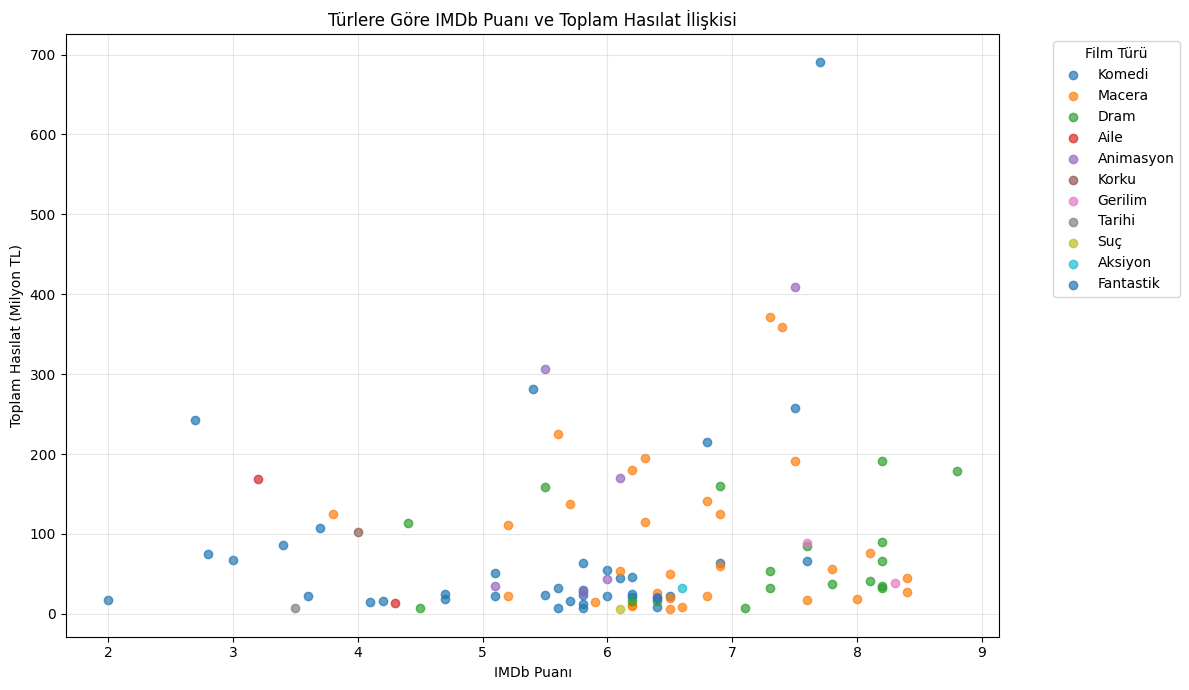

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Veriyi oku
df = pd.read_excel(r"C:\Users\Zeynep\OneDrive\Desktop\sinema-veri-analizi\sinema-veri-analizi\data\Son 10 yılın sinema filmleri.xlsx")

# Grafik boyutu
plt.figure(figsize=(12,7))

# Türleri al
ana_turler = df["ana_tur"].unique()

# Her tür için ayrı renk
for ana_tur in ana_turler:
    
    filtre = df[df["ana_tur"] == ana_tur]

    plt.scatter(
        filtre["imdb_puani"],
        filtre["toplam_hasilat"] / 1_000_000,
        alpha=0.7,
        label=ana_tur
    )

# Başlık
plt.title("Türlere Göre IMDb Puanı ve Toplam Hasılat İlişkisi")

# Eksenler
plt.xlabel("IMDb Puanı")
plt.ylabel("Toplam Hasılat (Milyon TL)")

# Grid
plt.grid(True, alpha=0.3)

# Legend
plt.legend(title="Film Türü", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig(
    "../images/imdb_hasilat_turler.png",
    dpi=300,
    bbox_inches="tight"
)


plt.tight_layout()
plt.show()

### Grafik Hakkında

Bu scatter plot grafik, IMDb puanı ile toplam hasılat arasındaki ilişkiyi film türlerine göre incelemek amacıyla oluşturulmuştur. Grafik üzerinde her nokta bir filmi temsil ederken, farklı renkler filmlerin türlerini göstermektedir.

Scatter plot tercih edilmesinin temel nedeni, iki sayısal değişken arasındaki ilişkiyi ve veri dağılımını en net şekilde gösterebilmesidir. Türlere göre renk ayrımı yapılması sayesinde yalnızca IMDb puanı ile hasılat ilişkisi değil, aynı zamanda hangi film türlerinin daha yüksek ticari başarı elde ettiği de analiz edilebilmektedir.

### Grafik Yorumu

Grafik incelendiğinde IMDb puanı ile toplam hasılat arasında tam doğrusal bir ilişki olmadığı görülmektedir. Yüksek IMDb puanına sahip bazı filmler düşük veya orta seviyede hasılat elde ederken, bazı filmler ise orta seviyede IMDb puanlarına rağmen oldukça yüksek hasılat değerlerine ulaşmıştır.

Özellikle macera, animasyon ve fantastik türündeki bazı filmlerin yüksek hasılat seviyelerine ulaştığı dikkat çekmektedir. Buna karşılık dram türündeki filmler genel olarak daha yüksek IMDb puanlarına sahip olsa da hasılat açısından daha dengeli bir dağılım göstermektedir.

Grafik genel olarak değerlendirildiğinde, film kalitesini temsil eden IMDb puanının ticari başarı üzerinde etkili olduğu görülse de tek belirleyici unsur olmadığı anlaşılmaktadır. Film türü, hedef kitle ve popülerlik gibi faktörlerin de toplam hasılat üzerinde önemli etkileri olduğu söylenebilir.


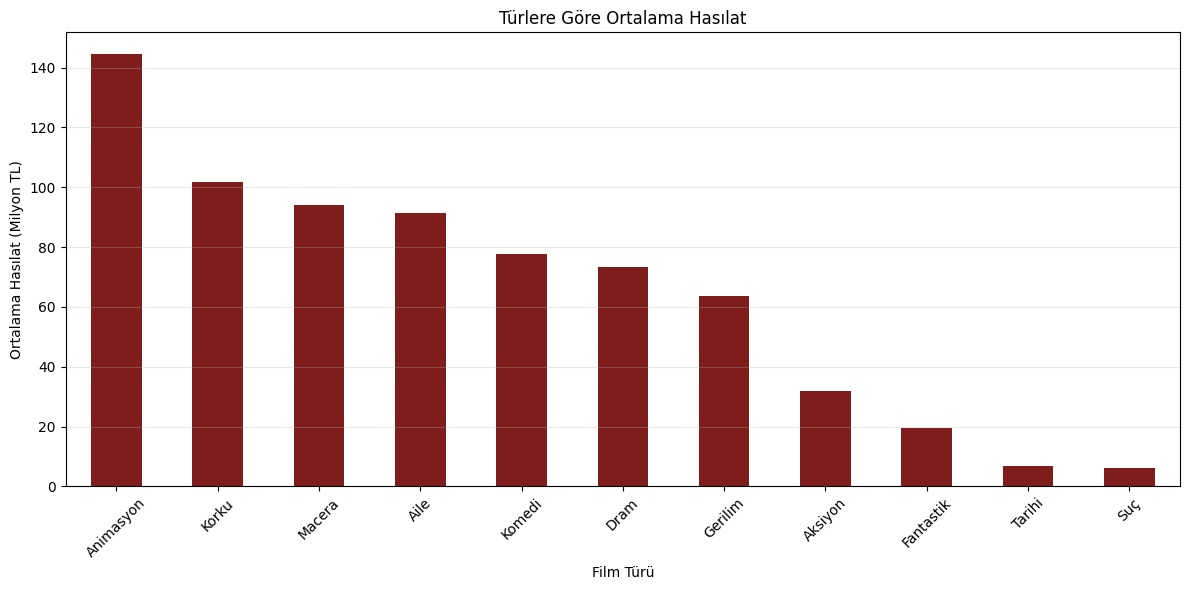

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Veriyi oku
df = pd.read_excel(r"C:\Users\Zeynep\OneDrive\Desktop\sinema-veri-analizi\sinema-veri-analizi\data\Son 10 yılın sinema filmleri.xlsx")

# Türlere göre ortalama hasılat
tur_hasilat = (
    df.groupby("ana_tur")["toplam_hasilat"]
      .mean()
      .sort_values(ascending=False)
)

# Milyon TL'ye çevir
tur_hasilat_milyon = tur_hasilat / 1_000_000

# Grafik
plt.figure(figsize=(12, 6))

tur_hasilat_milyon.plot(
    kind="bar",
    color="#7F1D1D"   # Mat bordo
)

plt.title("Türlere Göre Ortalama Hasılat")
plt.xlabel("Film Türü")
plt.ylabel("Ortalama Hasılat (Milyon TL)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../images/turlere_gore_ortalama_hasilat.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Grafik Hakkında

Bu grafik, film türlerine göre ortalama hasılat değerlerini karşılaştırmak amacıyla oluşturulmuştur. Bar chart tercih edilmesinin nedeni, kategorik değişkenler arasındaki sayısal farklılıkları açık ve anlaşılır bir şekilde gösterebilmesidir.

Bu analiz sayesinde yalnızca tekil film başarıları değil, belirli film türlerinin genel ticari performansları değerlendirilebilmektedir. Böylece hangi türlerin ortalama olarak daha yüksek gelir elde ettiği ve sinema sektöründe daha güçlü ticari sonuçlar ürettiği incelenebilmektedir.

### Grafik Yorumu
Grafik incelendiğinde en yüksek ortalama hasılata sahip türün animasyon olduğu görülmektedir. Animasyon filmleri yaklaşık 145 milyon TL ortalama hasılat ile diğer türlerin önünde yer almaktadır.

Animasyon türünü korku, macera ve aile türleri takip etmektedir. Bu türlerin ortalama hasılat değerlerinin diğer türlere göre daha yüksek olması, incelenen veri setindeki filmlerin ticari açıdan daha başarılı performans gösterdiğini ortaya koymaktadır.

Komedi, dram ve gerilim türleri orta seviyede ortalama hasılat değerlerine sahiptir. Buna karşılık fantastik, tarihi ve suç türleri en düşük ortalama hasılat değerlerini göstermektedir.

Sonuç olarak, incelenen veri setinde film türü ile ortalama hasılat arasında belirgin farklılıklar bulunmaktadır. Özellikle animasyon, korku ve macera türleri ticari başarı açısından öne çıkarken, tarihi ve suç türleri daha düşük ortalama hasılat üretmiştir.



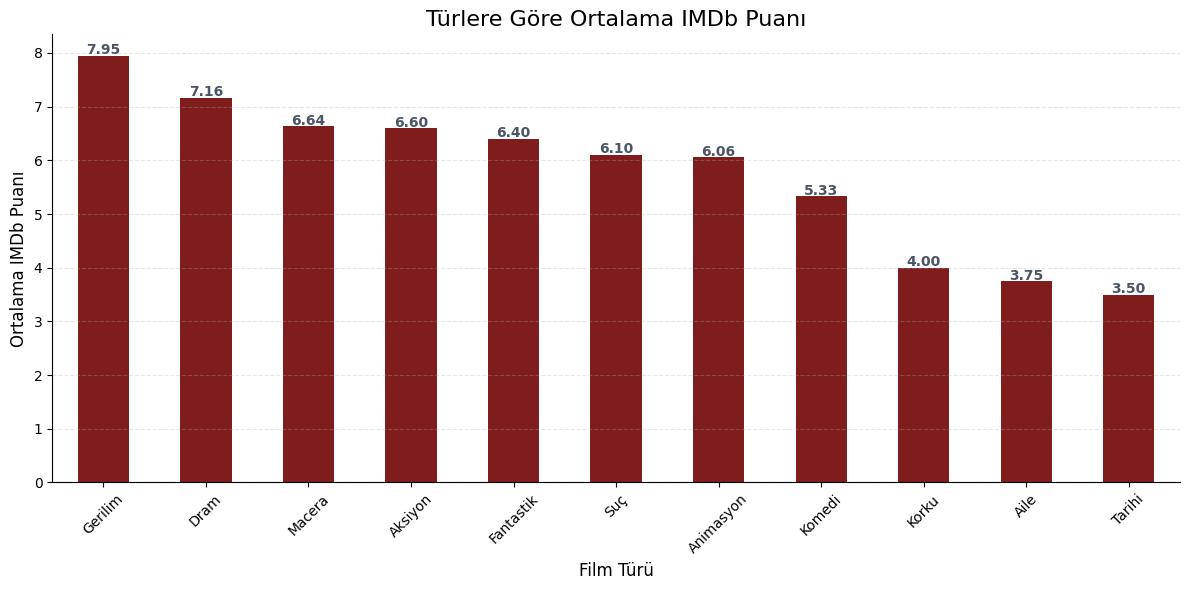

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Veriyi oku
df = pd.read_excel(
    r"C:\Users\Zeynep\OneDrive\Desktop\sinema-veri-analizi\sinema-veri-analizi\data\Son 10 yılın sinema filmleri.xlsx"
)

# Türlere göre ortalama IMDb
tur_imdb = (
    df.groupby("ana_tur")["imdb_puani"]
      .mean()
      .sort_values(ascending=False)
)

# Grafik
plt.figure(figsize=(12, 6))

tur_imdb.plot(
    kind="bar",
    color="#7F1D1D"   # Mat bordo
)

for i, v in enumerate(tur_imdb):
    plt.text(
        i,
        v + 0.03,
        f"{v:.2f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#4B5563"
    )
    
plt.title(
    "Türlere Göre Ortalama IMDb Puanı",
    fontsize=16
)

plt.xlabel("Film Türü", fontsize=12)
plt.ylabel("Ortalama IMDb Puanı", fontsize=12)

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Üst ve sağ kenarı kaldır
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../images/turlere_gore_ortalama_imdb.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Grafik Hakkında

Bu grafik, film türlerine göre ortalama IMDb puanlarını karşılaştırmak amacıyla oluşturulmuştur. Bar chart tercih edilmesinin nedeni, farklı film türlerinin ortalama puanlarını kolay ve anlaşılır bir şekilde karşılaştırabilmesidir.

Bu analiz sayesinde izleyicilerin hangi türleri daha yüksek değerlendirdiği ve izleyicilerin farklı film türlerini nasıl değerlendirdiği incelenebilmektedir. Ortalama IMDb puanlarının kullanılması, tek bir filmin etkisini azaltarak türlerin genel performansını değerlendirmeyi mümkün kılmaktadır.

### Grafik Yorumu

Grafik incelendiğinde en yüksek ortalama IMDb puanına sahip türün **gerilim** olduğu görülmektedir. Gerilim türü yaklaşık **7.95** ortalama IMDb puanıyla diğer tüm türlerin üzerinde yer almaktadır. Gerilim türünü **dram (7.16)** ve **macera (6.64)** takip etmektedir.

Buna karşılık **tarihi (3.50)**, **aile (3.75)** ve **korku (4.00)** türleri en düşük ortalama IMDb puanlarına sahiptir. Bu durum, veri setinde yer alan bu türdeki filmlerin izleyiciler tarafından daha düşük değerlendirildiğini göstermektedir.

Önceki grafikte incelenen ortalama hasılat değerleri ile birlikte değerlendirildiğinde dikkat çekici bir sonuç ortaya çıkmaktadır. En yüksek ortalama hasılata sahip olan **animasyon** türü, IMDb sıralamasında üst sıralarda yer almamaktadır. Benzer şekilde yüksek ortalama IMDb puanına sahip olan **gerilim** ve **dram** türleri ise hasılat sıralamasında ilk sırada bulunmamaktadır.

Bu sonuç, ticari başarı ile izleyici değerlendirmelerinin her zaman aynı doğrultuda ilerlemediğini göstermektedir. Bir filmin veya film türünün yüksek gelir elde etmesi, mutlaka en yüksek IMDb puanına sahip olduğu anlamına gelmemektedir.

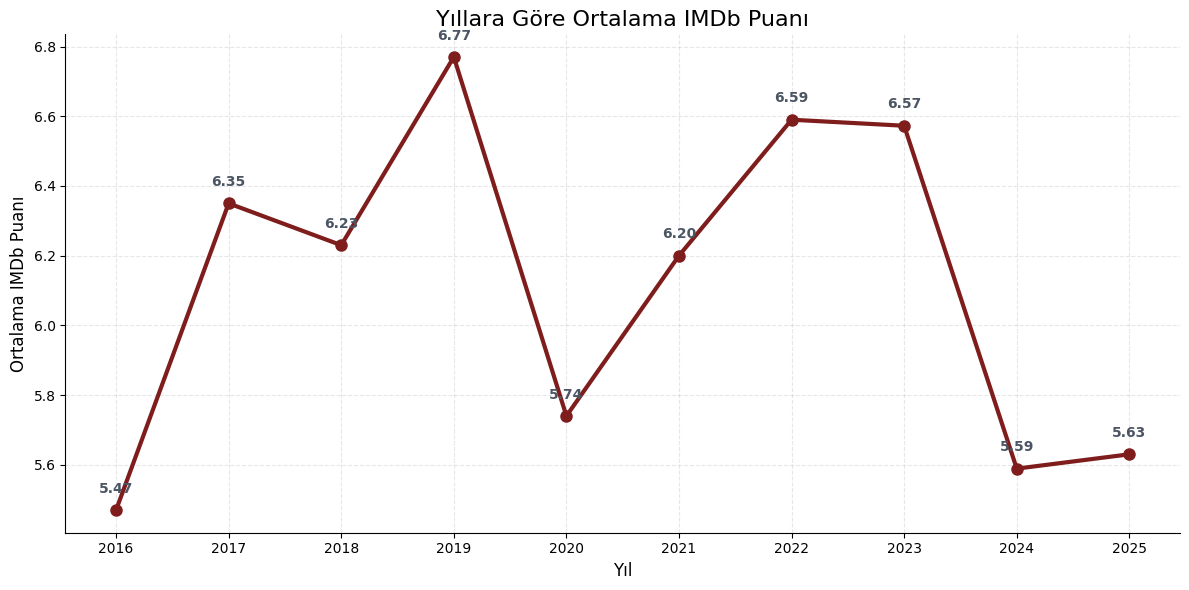

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Veriyi oku
df = pd.read_excel(
    r"C:\Users\Zeynep\OneDrive\Desktop\sinema-veri-analizi\sinema-veri-analizi\data\Son 10 yılın sinema filmleri.xlsx"
)

# Yıllara göre ortalama IMDb
yillik_imdb = (
    df.groupby("vizyon_tarihi")["imdb_puani"]
      .mean()
      .reset_index()
      .sort_values("vizyon_tarihi")
)

# Grafik
plt.figure(figsize=(12,6))

plt.plot(
    yillik_imdb["vizyon_tarihi"],
    yillik_imdb["imdb_puani"],
    marker="o",
    markersize=8,
    linewidth=3,
    color="#7F1D1D"
)

# Noktaların üzerine değerleri yaz
for x, y in zip(
    yillik_imdb["vizyon_tarihi"],
    yillik_imdb["imdb_puani"]
):
    plt.text(
        x,
        y + 0.05,
        f"{y:.2f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#4B5563"
    )

plt.title(
    "Yıllara Göre Ortalama IMDb Puanı",
    fontsize=16
)

plt.xlabel("Yıl", fontsize=12)
plt.ylabel("Ortalama IMDb Puanı", fontsize=12)

plt.grid(
    linestyle="--",
    alpha=0.3
)

# Üst ve sağ kenarı kaldır
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(
    yillik_imdb["vizyon_tarihi"],
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "../images/yillara_gore_ortalama_imdb.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Grafik Hakkında

Bu grafik, yıllara göre en çok izlenen filmlerin ortalama IMDb puanlarındaki değişimi incelemek amacıyla oluşturulmuştur. Çizgi grafik tercih edilmesinin nedeni, zaman içerisindeki değişimlerin ve eğilimlerin daha net bir şekilde gözlemlenebilmesidir.

Bu analiz sayesinde yıllar içerisinde popüler filmlerin izleyiciler tarafından nasıl değerlendirildiği ve ortalama IMDb puanlarının zamanla nasıl değiştiği incelenebilmektedir.

### Grafik Yorumu

Grafik incelendiğinde ortalama IMDb puanlarının yıllara göre dalgalı bir seyir izlediği görülmektedir. En yüksek ortalama IMDb puanı 2019 yılında yaklaşık **6.77** olarak gerçekleşirken, en düşük değer ise 2016 yılında yaklaşık **5.47** olarak gözlemlenmiştir.

2020 yılında ortalama IMDb puanında belirgin bir düşüş yaşanmış, ancak sonraki yıllarda tekrar yükselişe geçerek 2022 ve 2023 yıllarında **6.5** seviyelerinin üzerine çıkmıştır. Bu durum, söz konusu yıllarda en çok izlenen filmlerin izleyiciler tarafından daha olumlu değerlendirildiğini göstermektedir.

2024 yılında ortalama IMDb puanında yeniden düşüş görülmüş ve bu düşüş 2025 yılında da devam etmiştir. Ancak grafik genel olarak değerlendirildiğinde, yıllar arasında önemli dalgalanmalar bulunsa da ortalama IMDb puanlarının çoğunlukla **5.5 ile 6.8** aralığında toplandığı görülmektedir.

Sonuç olarak, en çok izlenen filmlerin IMDb puanları yıllar içerisinde değişiklik göstermiş olsa da belirgin ve sürekli bir artış veya azalış trendi gözlemlenmemektedir. Bu durum, popüler filmlerin izleyici değerlendirmelerinin dönemsel olarak değişebildiğini göstermektedir.

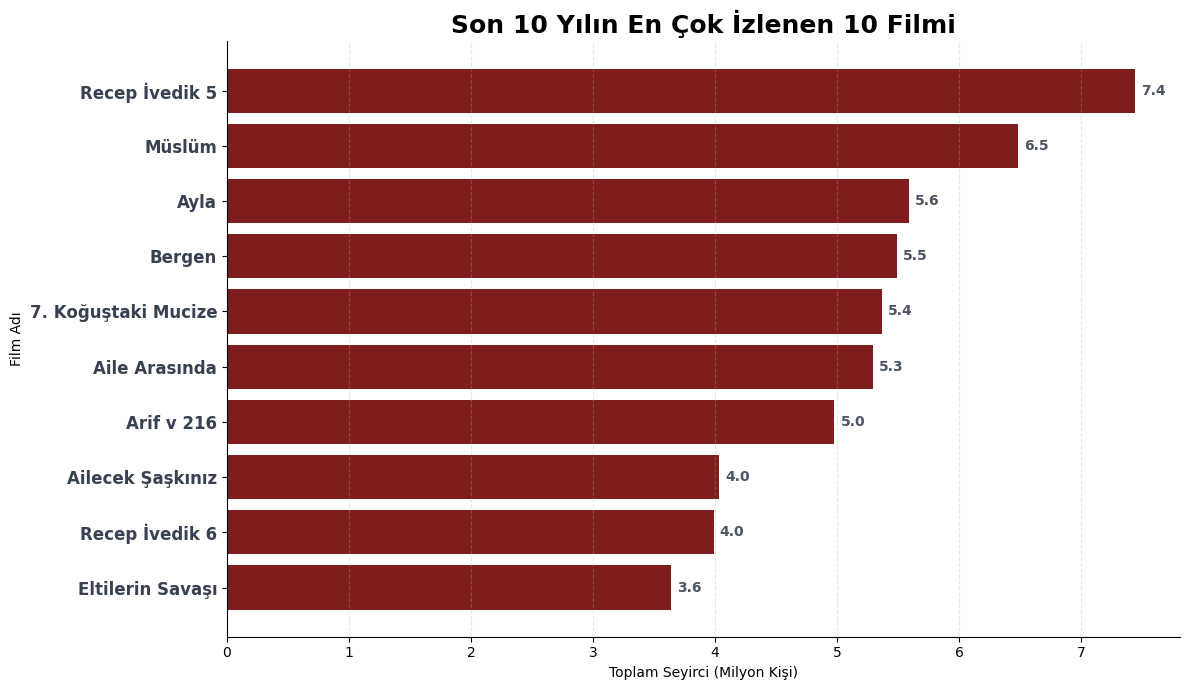

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Veriyi oku
df = pd.read_excel(
    r"C:\Users\Zeynep\OneDrive\Desktop\sinema-veri-analizi\sinema-veri-analizi\data\Son 10 yılın sinema filmleri.xlsx"
)

# En çok izlenen ilk 10 film
top10 = (
    df.nlargest(10, "toplam_seyirci")
      .sort_values("toplam_seyirci")
)

# Milyon kişi formatı
top10["seyirci_milyon"] = top10["toplam_seyirci"] / 1_000_000

# Grafik
plt.figure(figsize=(12, 7))

bars = plt.barh(
    top10["film_Adi"],   # sütun adı farklıysa değiştiririz
    top10["seyirci_milyon"],
    color="#7F1D1D"
)

# Değerleri yaz
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#4B5563"
    )

plt.title(
    "Son 10 Yılın En Çok İzlenen 10 Filmi",
    fontsize=16
)

plt.xlabel("Toplam Seyirci (Milyon Kişi)")
plt.ylabel("Film Adı")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# Kenarları sadeleştir
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.title(
    "Son 10 Yılın En Çok İzlenen 10 Filmi",
    fontsize=18,
    fontweight="bold"
)

plt.yticks(
    fontsize=12,
    fontweight="semibold",
    color="#374151"
)
plt.tight_layout()

plt.savefig(
    "../images/en_cok_izlenen_ilk10_film.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Grafik Hakkında

Bu grafik, veri setinde yer alan filmler arasından en yüksek seyirci sayısına ulaşan ilk 10 filmi göstermek amacıyla oluşturulmuştur. Yatay bar grafik tercih edilmesinin nedeni, film isimlerinin daha okunabilir şekilde gösterilebilmesi ve filmler arasındaki seyirci farklarının kolayca karşılaştırılabilmesidir.

Bu analiz sayesinde son 10 yıl içerisinde en fazla izleyiciye ulaşan filmler belirlenebilmekte ve filmler arasındaki seyirci sayısı farklılıkları incelenebilmektedir.

### Grafik Yorumu

Grafik incelendiğinde en yüksek seyirci sayısına ulaşan filmin **Recep İvedik 5** olduğu görülmektedir. Film yaklaşık **7,44 milyon** seyirciye ulaşarak listedeki diğer filmlerden belirgin şekilde ayrılmaktadır.

İkinci sırada yaklaşık **6,48 milyon** seyirci ile **Müslüm** yer almaktadır. Bu iki film, listedeki diğer filmlere göre daha yüksek seyirci sayılarına ulaşmıştır.

Üçüncü sıradan itibaren filmlerin seyirci sayılarının birbirine daha yakın olduğu görülmektedir. **Ayla**, **Bergen**, **7. Koğuştaki Mucize** ve **Aile Arasında** filmleri yaklaşık 5–5,6 milyon seyirci aralığında yer almaktadır.

Listenin son sıralarında bulunan filmler dahi 3,5 milyonun üzerinde seyirciye ulaşmıştır. Bu durum, grafikte yer alan tüm filmlerin kendi dönemlerinde oldukça yüksek izlenme sayılarına ulaştığını göstermektedir.

Sonuç olarak grafik, son 10 yıl içerisinde bazı filmlerin diğerlerine göre daha geniş kitlelere ulaştığını ve özellikle ilk iki filmin seyirci sayısı bakımından listedeki diğer yapımlardan ayrıştığını ortaya koymaktadır.


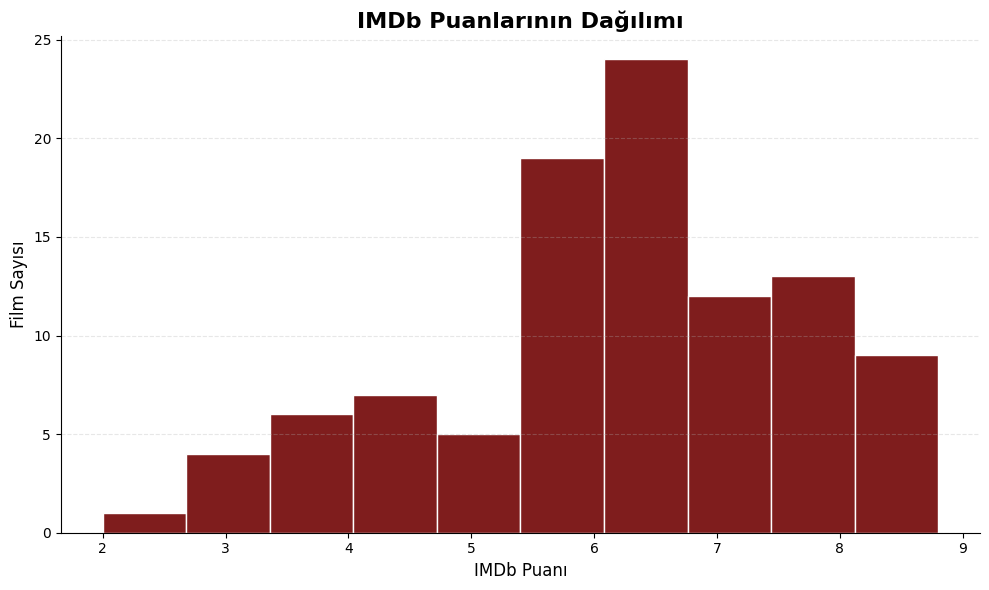

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Veriyi oku
df = pd.read_excel(
    r"C:\Users\Zeynep\OneDrive\Desktop\sinema-veri-analizi\sinema-veri-analizi\data\Son 10 yılın sinema filmleri.xlsx"
)

# Grafik
plt.figure(figsize=(10, 6))

plt.hist(
    df["imdb_puani"],
    bins=10,
    color="#7F1D1D",      # Mat bordo
    edgecolor="white"
)

plt.title(
    "IMDb Puanlarının Dağılımı",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("IMDb Puanı", fontsize=12)
plt.ylabel("Film Sayısı", fontsize=12)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Üst ve sağ kenarı kaldır
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../images/imdb_puani_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Grafik Hakkında

Bu grafik, veri setinde yer alan filmlerin IMDb puanlarının dağılımını incelemek amacıyla oluşturulmuştur. Histogram grafik tercih edilmesinin nedeni, IMDb puanlarının hangi aralıklarda yoğunlaştığını ve veri setindeki genel dağılımın daha net görülebilmesini sağlamasıdır.

Bu analiz sayesinde filmlerin IMDb puanlarının belirli değer aralıklarında toplanıp toplanmadığı incelenebilmekte ve veri setindeki puan dağılımının genel yapısı değerlendirilebilmektedir.

### Grafik Yorumu

Grafik incelendiğinde filmlerin IMDb puanlarının büyük bölümünün 5,5 ile 7,5 puan aralığında yoğunlaştığı görülmektedir. En yüksek frekansın yaklaşık 6–7 puan aralığında yer aldığı dikkat çekmektedir.

Düşük IMDb puanına sahip film sayısının görece az olduğu, benzer şekilde çok yüksek IMDb puanlarına sahip film sayısının da sınırlı olduğu görülmektedir. Bu durum, veri setinde yer alan filmlerin büyük çoğunluğunun orta ve orta-üst seviyede IMDb puanlarına sahip olduğunu göstermektedir.

IMDb puanlarının belirli bir aralıkta yoğunlaşması, veri setinde aşırı düşük veya aşırı yüksek puanlı filmlerin baskın olmadığını ortaya koymaktadır. Bu nedenle dağılımın büyük ölçüde orta değerler etrafında toplandığı söylenebilir.

Sonuç olarak grafik, veri setindeki filmlerin IMDb puanlarının çoğunlukla orta ve orta-üst puan aralıklarında kümelendiğini ve puan dağılımının belirli bir merkez etrafında yoğunlaştığını göstermektedir.

## Bulgular

* Veri setinde yer alan filmlerin IMDb puanları ağırlıklı olarak 5,5–7,5 puan aralığında yoğunlaşmaktadır. En yüksek yoğunluk yaklaşık 6–7 puan aralığında görülmektedir.

* Türlere göre ortalama IMDb puanları incelendiğinde gerilim ve dram türlerinin diğer türlere göre daha yüksek ortalama puanlara sahip olduğu görülmektedir.

* Ortalama IMDb puanları yıllara göre incelendiğinde yıllar arasında belirli dalgalanmalar bulunduğu, ancak genel olarak puanların 5,5–6,8 aralığında değiştiği gözlemlenmiştir.

* En yüksek seyirci sayısına ulaşan film Recep İvedik 5 olup yaklaşık 7,44 milyon seyirciye ulaşmıştır. Müslüm filmi ise yaklaşık 6,48 milyon seyirci ile ikinci sırada yer almaktadır.

* İlk sıralarda yer alan filmler ile listenin geri kalanındaki filmler arasında belirgin seyirci farkları bulunmaktadır. Özellikle ilk iki film diğer yapımlardan ayrışmaktadır.

* Yıllara göre toplam seyirci ve toplam hasılat birlikte incelendiğinde iki değişkenin zaman içerisinde benzer eğilimler gösterebildiği, ancak bazı dönemlerde farklı yönlerde değişim gösterebildiği görülmektedir.

* Türlere göre ortalama hasılat değerleri karşılaştırıldığında türler arasında önemli farklılıklar bulunduğu ve bazı türlerin daha yüksek ortalama hasılat değerlerine ulaştığı gözlemlenmiştir.


# Sonuç

Bu çalışmada son 10 yıla ait sinema verileri farklı açılardan incelenmiştir. Yapılan analizler sonucunda yıllara göre seyirci ve hasılat değişimleri, film türlerinin ortalama IMDb puanları ve hasılat performansları ile en çok izlenen filmler ortaya konulmuştur.

Grafikler incelendiğinde bazı yıllarda seyirci ve hasılat değerlerinde önemli değişimler yaşandığı, türler arasında belirgin farklılıklar bulunduğu ve bazı filmlerin seyirci sayısı bakımından diğerlerinden ayrıştığı görülmüştür. Ayrıca IMDb puanlarının büyük bölümünün orta ve orta-üst seviyelerde yoğunlaştığı tespit edilmiştir.

Elde edilen bulgular, Box Office Türkiye verileri kullanılarak oluşturulan veri setinin temel veri analizi ve veri görselleştirme yöntemleri ile anlamlı şekilde incelenebileceğini göstermektedir. Bu çalışma, sinema verilerinin istatistiksel yöntemler ve veri görselleştirme teknikleri kullanılarak yorumlanmasına yönelik uygulamalı bir örnek niteliğindedir.
